[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ReevesJustin/data-driven-reloading/blob/main/notebooks/01_The_Biggest_Lie_in_Reloading_Testing.ipynb)

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/ReevesJustin/data-driven-reloading/main?filepath=notebooks/01_The_Biggest_Lie_in_Reloading_Testing.ipynb)

Time to complete: 10-15 minutes

# The Biggest Lie in Reloading Testing

## Goal: Visually prove small samples mislead

**Simple simulation:** Same exact load (fixed true SD = 12 fps). Generate 1,000 shots.
Then repeatedly pull random 5-, 10-, or 20-shot strings. Plot their SDs.
**Interactive slider:** Change sample size → watch how often you get **"magical" ** single-digit SD by *pure chance*.
**Key takeaway:** "**A low SD over 10 shots proves almost nothing. It happens by luck more often than you think.**"
Repeat for group sizes: Show how **3×5-shot groups** can look amazing even from a mediocre rifle.

## Simulating Velocity Standard Deviation

This code creates a **fake rifle** with a true SD of 15 fps (like really good factory ammo). We generate 10,000 virtual shots, then pull random samples of 5, 10, 20, or 50 shots to see how their SDs vary. **SD** is how spread out the speeds are. Like how consistent your shots are.

In [1]:
# Imports and setup
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import ipywidgets as widgets
from IPython.display import display

# Set random seed for reproducibility
np.random.seed(42)

# True parameters for the simulation
true_mean_velocity = 2700  # fps
true_sd_velocity = 15      # fps

# Generate a large population of shots (10,000 shots)
population_velocities = np.random.normal(true_mean_velocity, true_sd_velocity, 10000)

# Function to sample velocities and compute SD
def sample_sd(n_shots):
    sample = np.random.choice(population_velocities, n_shots, replace=False)
    return np.std(sample, ddof=1)  # Sample standard deviation

# Simulate many samples for different sizes
sample_sizes = [5, 10, 20, 50]
n_simulations = 1000

sd_distributions = {}
for n in sample_sizes:
    sds = [sample_sd(n) for _ in range(n_simulations)]
    sd_distributions[n] = sds

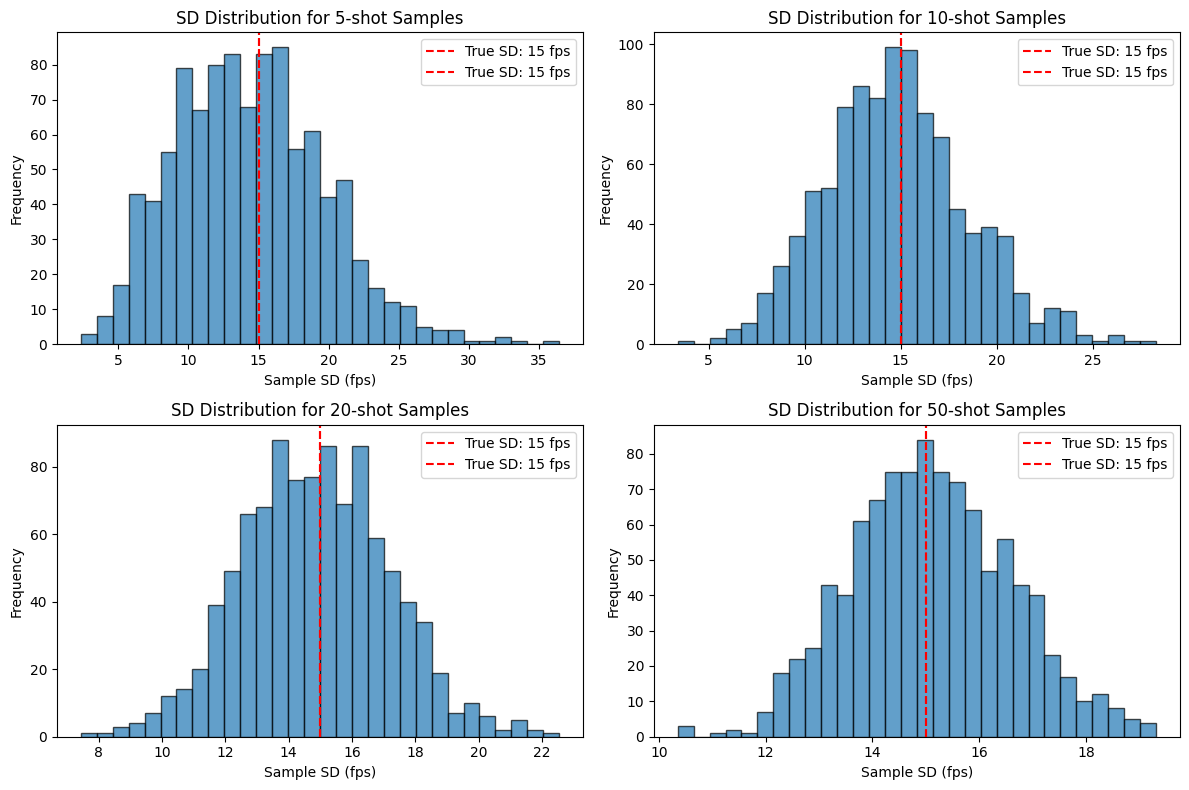

In [2]:
# Cell 2: Plot SD distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, n in enumerate(sample_sizes):
    ax = axes[i]
    ax.hist(sd_distributions[n], bins=30, alpha=0.7, edgecolor='black')
    ax.axvline(true_sd_velocity, color='red', linestyle='--', label=f'True SD: {true_sd_velocity} fps')
    ax.axvline(true_sd_velocity, color='red', linestyle='--', label=f'True SD: {true_sd_velocity} fps')
    ax.set_title(f'SD Distribution for {n}-shot Samples')
    ax.set_xlabel('Sample SD (fps)')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.show()

In [3]:
# Cell 3: Interactive slider for sample size
def plot_sd_distribution(n):
    sds = [sample_sd(n) for _ in range(n_simulations)]
    plt.figure(figsize=(8, 6))
    plt.hist(sds, bins=30, alpha=0.7, edgecolor='black')
    plt.axvline(true_sd_velocity, color='red', linestyle='--', label=f'True SD: {true_sd_velocity} fps')
    plt.axvline(true_sd_velocity, color='red', linestyle='--', label=f'True SD: {true_sd_velocity} fps')
    plt.title(f'SD Distribution for {n}-shot Samples')
    plt.xlabel('Sample SD (fps)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

# Create slider widget
slider = widgets.IntSlider(value=10, min=5, max=50, step=5, description='Sample Size:')
widgets.interactive(plot_sd_distribution, n=slider)

interactive(children=(IntSlider(value=10, description='Sample Size:', max=50, min=5, step=5), Output()), _dom_…

**Key Takeaway:** **A low SD over 10 shots proves almost nothing. It happens by luck more often than you think.**

In [4]:
# Cell 4: Simulation for group sizes
# True dispersion: let's say sigma = 0.5 MOA at 100 yards, but for simplicity, use inches
# Assume group center at (0,0), each shot normal(0, sigma) in x and y
true_group_sigma = 0.5  # inches at 100 yards (about 0.5 MOA)

# Generate population of shot positions
population_shots_x = np.random.normal(0, true_group_sigma, 10000)
population_shots_y = np.random.normal(0, true_group_sigma, 10000)

# Function to compute group size (extreme spread: max - min distance)
def compute_group_size(shots_x, shots_y):
    # Extreme spread: max distance between any two points
    points = np.column_stack((shots_x, shots_y))
    distances = [np.linalg.norm(p1 - p2) for i, p1 in enumerate(points) for p2 in points[i+1:]]
    return max(distances) if distances else 0

# Function to sample a group and compute size
def sample_group_size(n_shots):
    indices = np.random.choice(len(population_shots_x), n_shots, replace=False)
    group_x = population_shots_x[indices]
    group_y = population_shots_y[indices]
    return compute_group_size(group_x, group_y)

# Simulate many 5-shot groups
n_groups = 1000
group_sizes_5 = [sample_group_size(5) for _ in range(n_groups)]

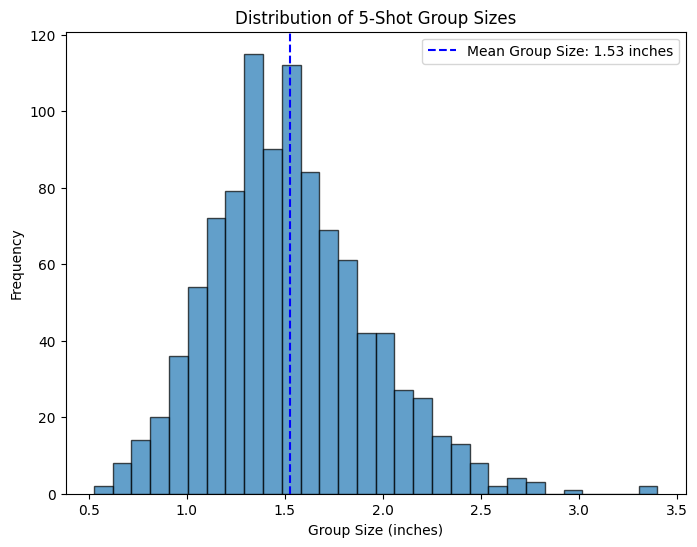

In [5]:
# Cell 5: Plot group size distribution for 5-shot groups
plt.figure(figsize=(8, 6))
plt.hist(group_sizes_5, bins=30, alpha=0.7, edgecolor='black')
plt.axvline(np.mean(group_sizes_5), color='blue', linestyle='--', label=f'Mean Group Size: {np.mean(group_sizes_5):.2f} inches')
plt.title('Distribution of 5-Shot Group Sizes')
plt.xlabel('Group Size (inches)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

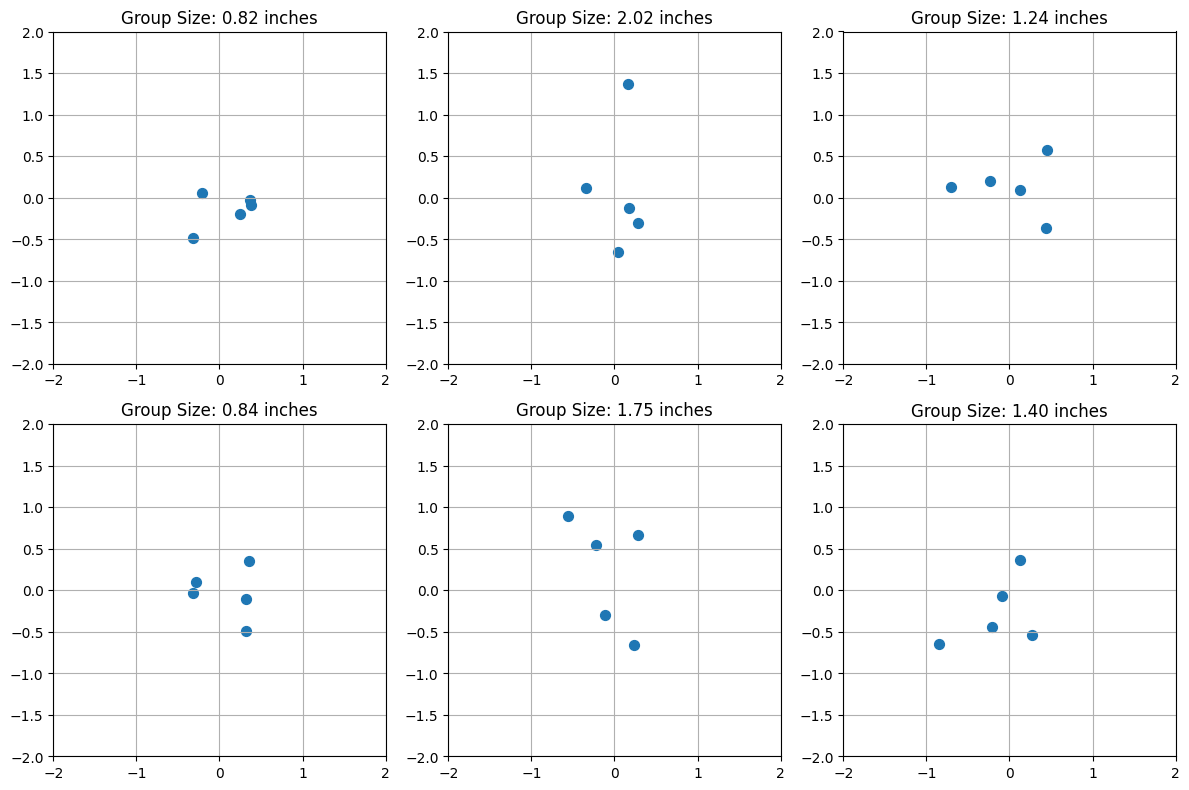

In [6]:
# Cell 6: Example: Show a few random 5-shot groups
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for i in range(6):
    ax = axes.flat[i]
    indices = np.random.choice(len(population_shots_x), 5, replace=False)
    group_x = population_shots_x[indices]
    group_y = population_shots_y[indices]
    ax.scatter(group_x, group_y, s=50)
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.set_aspect('equal')
    group_size = compute_group_size(group_x, group_y)
    ax.set_title(f'Group Size: {group_size:.2f} inches')
    ax.grid(True)

plt.tight_layout()
plt.show()

> **Key Takeaways**
> - Small sample sizes in reloading tests lead to unreliable results
> - Statistical significance requires adequate sample sizes
> - Common testing practices often fail to detect real differences
> - Simulation shows how luck can create false positives
> - Proper testing methodology prevents chasing illusions

[Previous: 00_Welcome_and_Why_This_Matters.ipynb](00_Welcome_and_Why_This_Matters.ipynb) | [Next: 02_What_We_Actually_Mean_by_Consistency.ipynb](02_What_We_Actually_Mean_by_Consistency.ipynb)